In [78]:
import jax.numpy as jnp
import jax.lax as lax
from jax import jit, tree_util
from functools import partial
from matplotlib import pyplot as plt
import diffrax as dif
import pandas as pd

# Plot-Formatierung
plt.rcParams['font.size'] = 24.0
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelsize'] = 'medium'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['lines.linewidth'] = 2.0

#Formulierung des Anfangswertproblems
f = lambda params, z, u: jnp.array([u[1], params[0] * u[0] + params[1] * jnp.sin(z)])

z0 = 0.
z1 = 40.
u0 = jnp.array([1., -0.5])
params = jnp.array([0.01, 0.505])

In [79]:
@partial(jit, static_argnames=['f', 'n'])
def eigenerSolverV2(params, z0, z1, u0, f, n):
    dz = (z1-z0)/(n-1)

    # Runge-Kutta 4. Ordnung
    def rk4_step(params, z0, dz, u0, f):
        k1 = dz * f(params, z0, u0)
        k2 = dz * f(params, z0 + dz / 2, u0 + k1 / 2)
        k3 = dz * f(params, z0 + dz / 2, u0 + k2 / 2)
        k4 = dz * f(params, z0 + dz, u0 + k3)
        u1 = u0 + (k1 + 2 * k2 + 2 * k3 + k4) / 6
        return u1

    def rk4_step_scan(u, x):
        return rk4_step(params, x, dz, u, f), \
            rk4_step(params, x, dz, u, f)

    zs = jnp.linspace(z0, z1, n)
    _, uz = lax.scan(rk4_step_scan, u0, zs[:-1])
    uz = jnp.concatenate([jnp.array([u0]), uz], axis=0)

    return uz, zs

@partial(jit, static_argnames=['f', 'n', 'rtol', 'atol', 'max_steps']) 
def diffraxDopri5(params, z0, z1, u0, f, n, rtol, atol, max_steps):

    vector_field = lambda z, y, args: f(args, z, y) #wrapper für reihenfolge
    term = dif.ODETerm(vector_field)
    solver = dif.Dopri5()
    saveat = dif.SaveAt(steps=True)
    stepsize_controller = dif.PIDController(rtol=rtol, atol=atol)

    sol = dif.diffeqsolve(  term, solver, 
                            t0=z0, t1=z1, dt0=None, y0=u0, args=(params), 
                            saveat=saveat,
                            adjoint=dif.DirectAdjoint(),
                            stepsize_controller=stepsize_controller,
                            max_steps=max_steps)

    zs = sol.ts
    uz = sol.ys

    return uz, zs

@partial(jit, static_argnames=['f', 'n', 'rtol', 'atol']) 
def diffraxDopri5n(params, z0, z1, u0, f, n, rtol, atol):

    vector_field = lambda z, y, args: f(args, z, y) #wrapper für reihenfolge
    term = dif.ODETerm(vector_field)
    solver = dif.Dopri5()
    saveat = dif.SaveAt(ts=jnp.linspace(0, z1, n))
    stepsize_controller = dif.PIDController(rtol=rtol, atol=atol)

    sol = dif.diffeqsolve(  term, solver, 
                            t0=z0, t1=z1, dt0=None, y0=u0, args=(params), 
                            saveat=saveat,
                            adjoint=dif.DirectAdjoint(),
                            stepsize_controller=stepsize_controller,
                            max_steps=None)

    zs = sol.ts
    uz = sol.ys

    return uz, zs

f_analytical = lambda z: jnp.cosh(0.1*z) - 0.5*jnp.sin(z)

def block_until_ready(pytree):
  return tree_util.tree_map(lambda x: x.block_until_ready(), pytree)

In [80]:
from scipy.optimize import curve_fit

def linreg(x,y,ey,ini=[1,1]):

    def func(x, m, b):
        return m*x + b
    
    popt, pcov = curve_fit(func, x, y, p0=ini, sigma=ey, absolute_sigma=True)
    perr = jnp.sqrt(jnp.diag(pcov))

    xi = y
    Xi = func(x, *popt)
    chiq = jnp.sum((xi-Xi)**2 / ey**2)
    ndof = len(xi)-2

    return popt[0], perr[0], popt[1], perr[1], chiq, ndof       



def residuenplot(var_x, unit_x, v_x, v_s_x, var_y, unit_y, v_y, v_s_y, m, b, chiq, name='', save=False, Zoom = None):
    
    fig, axarray = plt.subplots(2, 1, figsize=(20,10), sharex=True, gridspec_kw={'height_ratios': [5, 2]})
    plt.title(name)
    if Zoom != None:
        axarray[0].set_xlim(*Zoom)
        axarray[0].set_ylim(*Zoom)
    axarray[0].errorbar(v_x, v_y, xerr=v_s_x, yerr=v_s_y, color='red', fmt='o', markeredgecolor='red', label='Messwerte')
    axarray[0].set_xlabel('${0}$ / ${1}$'.format(var_x, unit_x))
    axarray[0].set_ylabel('${0}$ / ${1}$'.format(var_y, unit_y))
    axarray[0].plot(v_x, m*v_x+b, color='green', label='${0:.2f}*x+{1:.2f}$'.format(m, b))
    sigmaRes = jnp.sqrt((m*v_s_x)**2 + v_s_y**2)
    axarray[1].axhline(y=0., color='black', linestyle='--')
    axarray[1].errorbar(v_x, v_y-(m*v_x+b), yerr=sigmaRes, color='red', fmt='o', markeredgecolor='red')
    axarray[1].set_xlabel('${0}$ / ${1}$'.format(var_x, unit_x))
    axarray[1].set_ylabel('Residuen')
    plt.figtext(0.14,0.7,'chi2/ndf = %.2f / %.0f = %.2f' % (chiq, len(v_x)-2, chiq/(len(v_x)-2)))
    axarray[0].legend()
    axarray[0].grid()
    ymax = max([abs(x) for x in axarray[1].get_ylim()])
    axarray[1].set_ylim(-ymax, ymax)
    plt.tight_layout()
    plt.grid()
    fig.subplots_adjust(hspace=0.0)
    
    if save == True:
        plt.savefig(name)
    
    plt.show() 

In [81]:
ns = [5, 10, 20, 50, 100, 200, 500, 750, 1000, 1500, 2000]

df_e = pd.DataFrame(columns=['n', 'abw_mean_eigen', 'abw_max_eigen', 't_mean', 't_std'])

for n in ns:
    uz_eigen, zs_eigen = eigenerSolverV2(params, z0, z1, u0, f, n)
    t = %timeit -o block_until_ready(eigenerSolverV2(params, z0, z1, u0, f, n))

    abw_eigen = jnp.array([uz_eigen[i,0] - f_analytical(zs_eigen[i]) for i in range(n)])
    abw_mean_eigen = jnp.mean(jnp.abs(abw_eigen))
    abw_max_eigen = jnp.max(jnp.abs(abw_eigen))

    df_e = pd.concat([df_e, pd.DataFrame({'n': [n], 'abw_mean_eigen': [abw_mean_eigen], 'abw_max_eigen': [abw_max_eigen], 't_mean': [t.average], 't_std': [t.stdev]})], ignore_index=True)

df_e.to_string('results/benchmark_eigen3.txt', col_space=16, justify='left', index=False, float_format = '{:.2e}'.format)

8.08 µs ± 217 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


C:\Users\Ruben\AppData\Local\Temp\ipykernel_95460\577438145.py:13: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_e = pd.concat([df_e, pd.DataFrame({'n': [n], 'abw_mean_eigen': [abw_mean_eigen], 'abw_max_eigen': [abw_max_eigen], 't_mean': [t.average], 't_std': [t.stdev]})], ignore_index=True)


8.11 µs ± 107 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
8.29 µs ± 47.5 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
9.24 µs ± 74.1 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
10.9 µs ± 65.7 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
14.3 µs ± 60.5 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
23.9 µs ± 113 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
32.8 µs ± 652 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
40.4 µs ± 189 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
58.3 µs ± 428 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
73.8 µs ± 763 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


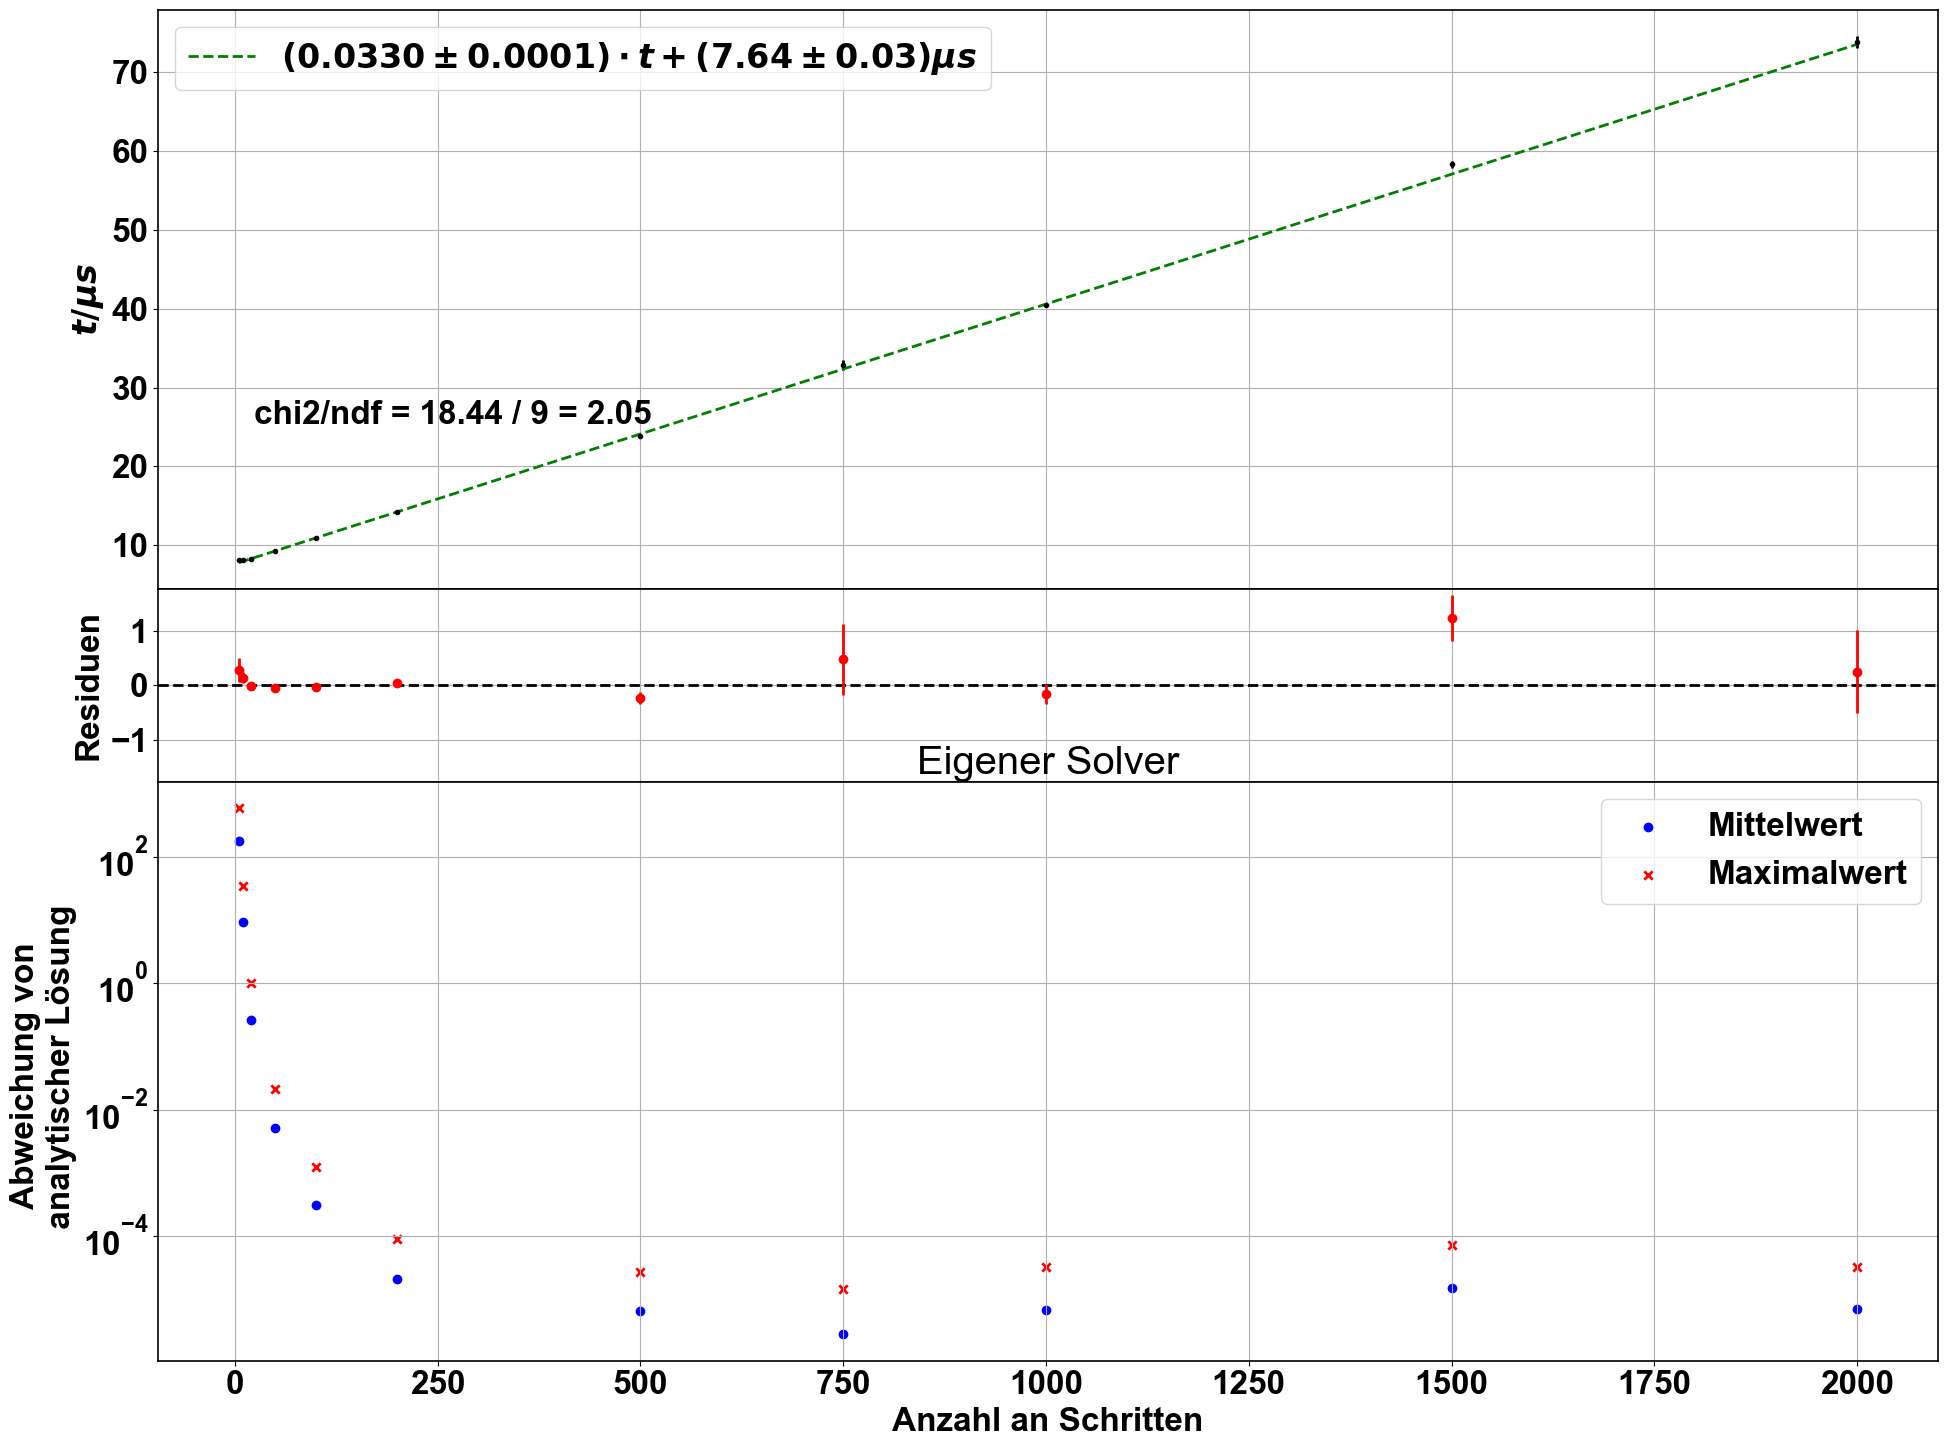

In [82]:
# Plot
x = jnp.array(df_e['n'].to_numpy(), dtype=jnp.float32)
y = jnp.array(df_e['t_mean'])*1e+6
ey = jnp.array(df_e['t_std'])*1e+6
m, em, b, eb, chiq, ndof = linreg(x, y, ey, ini=[1,1])

fig, ax = plt.subplots(3,1, figsize=(20,15), sharex=True, gridspec_kw={'height_ratios': [3, 1, 3]})
plt.title('Eigener Solver')
ax[0].set_ylabel('$t/\mu s$')
ax[0].errorbar(x, y, yerr=ey, color='black', fmt = '.')
ax[0].plot(x, m*x+b, color='green', linestyle='--', label='$({0:.4f} \pm {2:.4f}) \cdot t+({1:.2f} \pm {3:.2f})\mu s$'.format(m, b, em, eb))
ax[0].grid()
ax[0].legend()
sigmaRes = ey
ax[1].axhline(y=0., color='black', linestyle='--')
ax[1].errorbar(x, y-(m*x+b), yerr=sigmaRes, color='red', fmt='o', markeredgecolor='red')
ax[1].set_ylabel('Residuen')
plt.figtext(0.14,0.7,'chi2/ndf = %.2f / %.0f = %.2f' % (chiq, len(x)-2, chiq/(len(x)-2)))
ax[1].grid()
ymax = max([abs(x) for x in ax[1].get_ylim()])
ax[1].set_ylim(-ymax, ymax)
ax[2].set_xlabel('Anzahl an Schritten')
ax[2].set_ylabel('Abweichung von \n analytischer Lösung')
ax[2].set_yscale('log')
ax[2].scatter(df_e['n'], df_e['abw_mean_eigen'], color='blue', label='Mittelwert', marker='o')
ax[2].scatter(df_e['n'], df_e['abw_max_eigen'], color='red', label='Maximalwert', marker='x')
ax[2].grid()
ax[2].legend()
fig.tight_layout()
fig.subplots_adjust(hspace=0.0)
plt.savefig('results/benchmark_eigen3.png')


In [83]:
rtol = 0
atols = [1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8, 1e-9, 2e-10, 3e-10, 5e-10, 7e-10, 1e-10]

df_da = pd.DataFrame(columns=['atol', 'abw_mean_dopri', 'abw_max_dopri', 'n', 't_mean', 't_std'])

for atol in atols:
    uz_dopri, zs_dopri = diffraxDopri5(params, z0, z1, u0, f, n, rtol, atol, 4096)
    t = %timeit -o block_until_ready(diffraxDopri5(params, z0, z1, u0, f, n, rtol, atol, 4096))

    uz_dopri = uz_dopri[~jnp.isinf(uz_dopri).any(axis=1)]
    zs_dopri = zs_dopri[~jnp.isinf(zs_dopri)]

    abw_dopri = jnp.array([uz_dopri[i,0] - f_analytical(zs_dopri[i]) for i in range(len(zs_dopri))])
    abw_mean_dopri = jnp.mean(jnp.abs(abw_dopri))
    abw_max_dopri = jnp.max(jnp.abs(abw_dopri))

    df_da = pd.concat([df_da, pd.DataFrame({'atol':[atol], 'abw_mean_dopri': [abw_mean_dopri], 'abw_max_dopri': [abw_max_dopri], 'n': [len(zs_dopri)], 't_mean': [t.average], 't_std': [t.stdev]})], ignore_index=True)



df_da.to_string('results/benchmark_dopria3.txt', col_space=16, justify='left', index=False, float_format = '{:.2e}'.format)


171 µs ± 527 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


C:\Users\Ruben\AppData\Local\Temp\ipykernel_95460\3917309133.py:17: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_da = pd.concat([df_da, pd.DataFrame({'atol':[atol], 'abw_mean_dopri': [abw_mean_dopri], 'abw_max_dopri': [abw_max_dopri], 'n': [len(zs_dopri)], 't_mean': [t.average], 't_std': [t.stdev]})], ignore_index=True)


174 µs ± 972 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
174 µs ± 888 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
176 µs ± 782 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
182 µs ± 1.28 µs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
186 µs ± 653 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
196 µs ± 747 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
219 µs ± 10.7 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
257 µs ± 4.5 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
471 µs ± 3.62 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
380 µs ± 7.84 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
313 µs ± 4.28 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
275 µs ± 1.91 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
768 µs ± 3.53 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


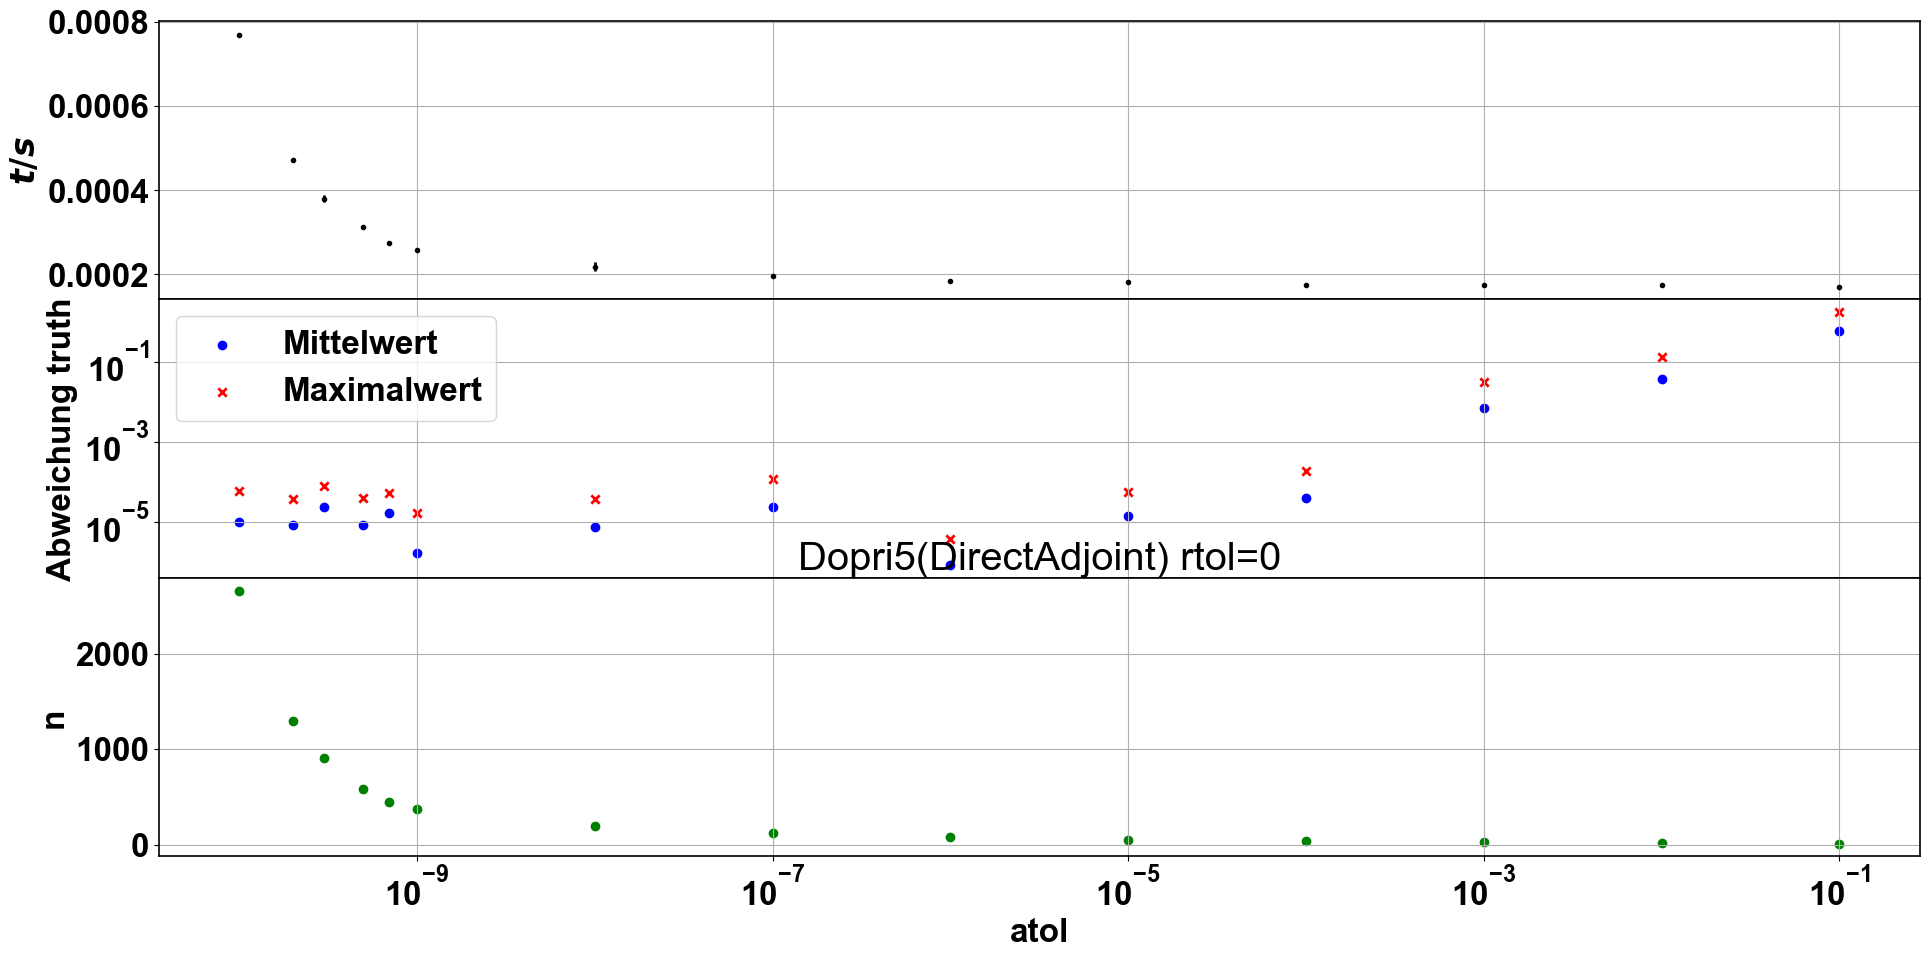

In [84]:
# Plot
fig, ax = plt.subplots(3,1, figsize=(20,10), sharex=True, gridspec_kw={'height_ratios': [3, 3, 3]})
plt.title('Dopri5(DirectAdjoint) rtol=0')
ax[0].set_ylabel('$t/s$')
ax[0].errorbar(df_da['atol'], df_da['t_mean'], yerr=df_da['t_std'], color='black', fmt = '.')
ax[0].grid()
ax[1].set_ylabel('Abweichung truth')
ax[1].set_yscale('log')
ax[1].scatter(df_da['atol'], df_da['abw_mean_dopri'], color='blue', label='Mittelwert', marker='o')
ax[1].scatter(df_da['atol'], df_da['abw_max_dopri'], color='red', label='Maximalwert', marker='x')
ax[1].grid()
ax[1].legend()
ax[2].set_xlabel('atol')
ax[2].set_xscale('log')
ax[2].set_ylabel('n')
ax[2].scatter(df_da['atol'], df_da['n'], color='green', marker='o')
ax[2].grid()
fig.tight_layout()
fig.subplots_adjust(hspace=0.0)
plt.savefig('results/benchmark_dopria3.png')

In [94]:
ns = [100, 500, 1000, 1500, 2000, 3000, 4000, 5000, 6000]
rtol = 0
atol = 1e-6

df_dn = pd.DataFrame(columns=['abw_mean_dopri', 'abw_max_dopri', 'n', 't_mean', 't_std'])

for n in ns:
    uz_doprin, zs_doprin = diffraxDopri5n(params, z0, z1, u0, f, n, rtol, atol)
    t = %timeit -o block_until_ready(diffraxDopri5n(params, z0, z1, u0, f, n, rtol, atol))

    abw_doprin = jnp.array([uz_doprin[i,0] - f_analytical(zs_doprin[i]) for i in range(n)])
    abw_mean_doprin = jnp.mean(jnp.abs(abw_doprin))
    abw_max_doprin = jnp.max(jnp.abs(abw_doprin))

    df_dn = pd.concat([df_dn, pd.DataFrame({'abw_mean_dopri': [abw_mean_doprin], 'abw_max_dopri': [abw_max_doprin], 'n': [n], 't_mean': [t.average], 't_std': [t.stdev]})], ignore_index=True)



df_dn.to_string('results/benchmark_doprin3.txt', col_space=16, justify='left', index=False, float_format = '{:.2e}'.format)

184 µs ± 863 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


C:\Users\Ruben\AppData\Local\Temp\ipykernel_95460\2875919328.py:15: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_dn = pd.concat([df_dn, pd.DataFrame({'abw_mean_dopri': [abw_mean_doprin], 'abw_max_dopri': [abw_max_doprin], 'n': [n], 't_mean': [t.average], 't_std': [t.stdev]})], ignore_index=True)


186 µs ± 842 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
191 µs ± 1.72 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
195 µs ± 916 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
199 µs ± 1.1 µs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
207 µs ± 2.39 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
212 µs ± 856 ns per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
304 µs ± 5.44 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
306 µs ± 1.59 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


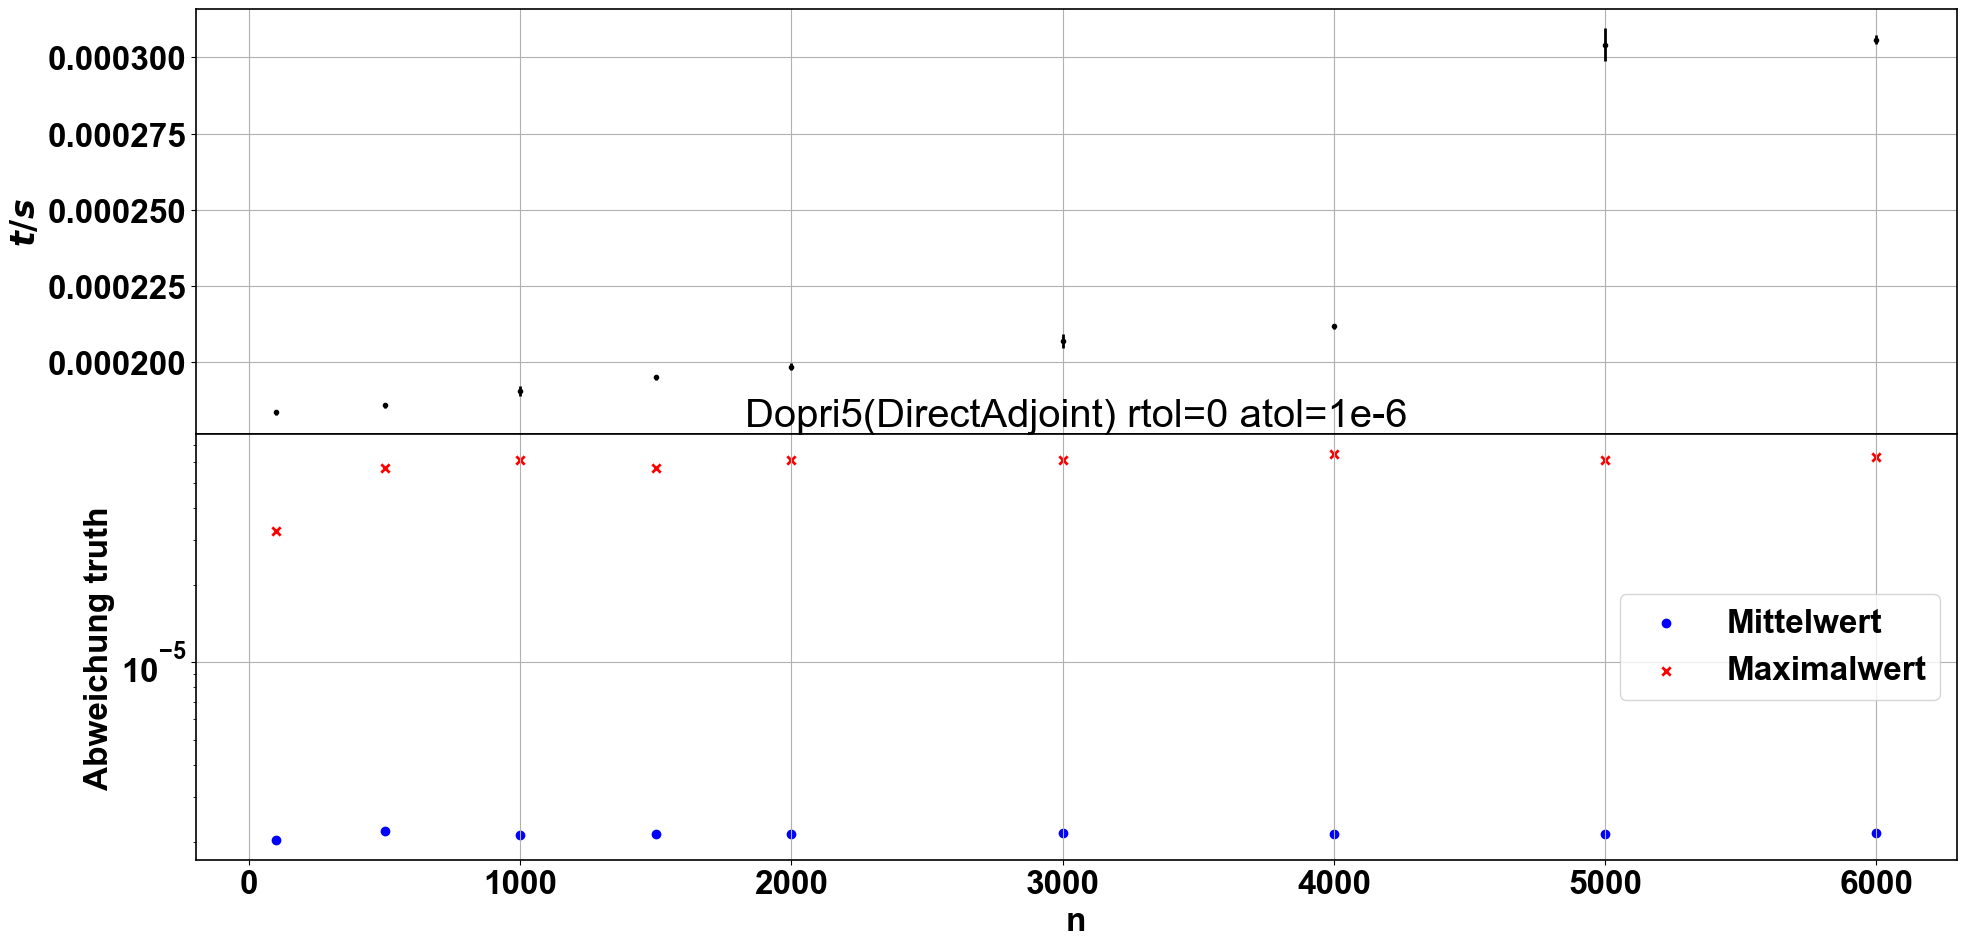

In [96]:
# Plot
fig, ax = plt.subplots(2,1, figsize=(20,10), sharex=True, gridspec_kw={'height_ratios': [3, 3]})
plt.title('Dopri5(DirectAdjoint) rtol=0 atol=1e-6')
ax[0].set_ylabel('$t/s$')
#ax[0].set_yscale('log')
ax[0].errorbar(df_dn['n'], df_dn['t_mean'], yerr=df_dn['t_std'], color='black', fmt = '.')
ax[0].grid()
ax[1].set_ylabel('Abweichung truth')
ax[1].set_yscale('log')
ax[1].scatter(df_dn['n'], df_dn['abw_mean_dopri'], color='blue', label='Mittelwert', marker='o')
ax[1].scatter(df_dn['n'], df_dn['abw_max_dopri'], color='red', label='Maximalwert', marker='x')
ax[1].grid()
ax[1].legend()
ax[1].set_xlabel('n')
#ax[1].set_xscale('log')
fig.tight_layout()
fig.subplots_adjust(hspace=0.0)
plt.savefig('results/benchmark_doprin3.png')

In [87]:
# rtols = [1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8, 2e-9, 3e-9, 5e-9, 7e-9, 1e-9]
# atol = 0

# df_dr = pd.DataFrame(columns=['rtol', 'rel_abw_mean_dopri', 'rel_abw_max_dopri', 'n', 't_mean', 't_std'])

# for rtol in rtols:
#     uz_dopri, zs_dopri = diffraxDopri5(params, z0, z1, u0, f, n, rtol, atol, 4096)
#     t = %timeit -o block_until_ready(diffraxDopri5(params, z0, z1, u0, f, n, rtol, atol, 4096))

#     uz_dopri = uz_dopri[~jnp.isinf(uz_dopri).any(axis=1)]
#     zs_dopri = zs_dopri[~jnp.isinf(zs_dopri)]

#     rel_abw_dopri = jnp.array([(uz_dopri[i,0] - f_analytical(zs_dopri[i]) )/f_analytical(zs_dopri[i]) for i in range(len(zs_dopri))])
#     rel_abw_mean_dopri = jnp.mean(jnp.abs(rel_abw_dopri))
#     rel_abw_max_dopri = jnp.max(jnp.abs(rel_abw_dopri))

#     df_dr = pd.concat([df_dr, pd.DataFrame({'rtol':[rtol], 'rel_abw_mean_dopri': [rel_abw_mean_dopri], 'rel_abw_max_dopri': [rel_abw_max_dopri], 'n': [len(zs_dopri)], 't_mean': [t.average], 't_std': [t.stdev]})], ignore_index=True)



# df_dr.to_string('results/benchmark_doprir3.txt', col_space=16, justify='left', index=False, float_format = '{:.2e}'.format)

In [88]:
# # Plot
# fig, ax = plt.subplots(3,1, figsize=(20,10), sharex=True, gridspec_kw={'height_ratios': [3, 3, 3]})
# plt.title('Dopri5(DirectAdjoint) rtol=0')
# ax[0].set_ylabel('$t/s$')
# #ax[0].set_yscale('log')
# ax[0].errorbar(df_dr['rtol'], df_dr['t_mean'], yerr=df_dr['t_std'], color='black', fmt = '.')
# ax[0].grid()
# ax[1].set_ylabel('rel. Abweichung truth')
# ax[1].set_yscale('log')
# ax[1].scatter(df_dr['rtol'], df_dr['rel_abw_mean_dopri'], color='blue', label='Mittelwert', marker='o')
# ax[1].scatter(df_dr['rtol'], df_dr['rel_abw_max_dopri'], color='red', label='Maximalwert', marker='x')
# ax[1].grid()
# ax[1].legend()
# ax[2].set_xlabel('rtol')
# ax[2].set_xscale('log')
# ax[2].set_ylabel('n')
# ax[2].scatter(df_dr['rtol'], df_dr['n'], color='green', marker='o')
# ax[2].grid()
# fig.tight_layout()
# fig.subplots_adjust(hspace=0.0)

In [89]:
rtol = 0
atol = 1e-6
max_steps_ = [256, 4096, 65635, 1048576, 16777216]


df_ds = pd.DataFrame(columns=['max_steps', 'abw_mean_dopri', 'abw_max_dopri', 'n', 't_mean', 't_std'])

for max_steps in max_steps_:
    uz_dopri, zs_dopri = diffraxDopri5(params, z0, z1, u0, f, n, rtol, atol, max_steps)
    t = %timeit -o block_until_ready(diffraxDopri5(params, z0, z1, u0, f, n, rtol, atol, max_steps))

    uz_dopri = uz_dopri[~jnp.isinf(uz_dopri).any(axis=1)]
    zs_dopri = zs_dopri[~jnp.isinf(zs_dopri)]

    abw_dopri = jnp.array([uz_dopri[i,0] - f_analytical(zs_dopri[i]) for i in range(len(zs_dopri))])
    abw_mean_dopri = jnp.mean(jnp.abs(abw_dopri))
    abw_max_dopri = jnp.max(jnp.abs(abw_dopri))

    df_ds = pd.concat([df_ds, pd.DataFrame({'max_steps':[max_steps], 'abw_mean_dopri': [abw_mean_dopri], 'abw_max_dopri': [abw_max_dopri], 'n': [len(zs_dopri)], 't_mean': [t.average], 't_std': [t.stdev]})], ignore_index=True)



df_ds.to_string('results/benchmark_dopris3.txt', col_space=16, justify='left', index=False, float_format = '{:.2e}'.format)

184 µs ± 528 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


C:\Users\Ruben\AppData\Local\Temp\ipykernel_95460\4255799064.py:19: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_ds = pd.concat([df_ds, pd.DataFrame({'max_steps':[max_steps], 'abw_mean_dopri': [abw_mean_dopri], 'abw_max_dopri': [abw_max_dopri], 'n': [len(zs_dopri)], 't_mean': [t.average], 't_std': [t.stdev]})], ignore_index=True)


189 µs ± 899 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
299 µs ± 4.11 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
1.36 ms ± 12.9 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
16.1 ms ± 72 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


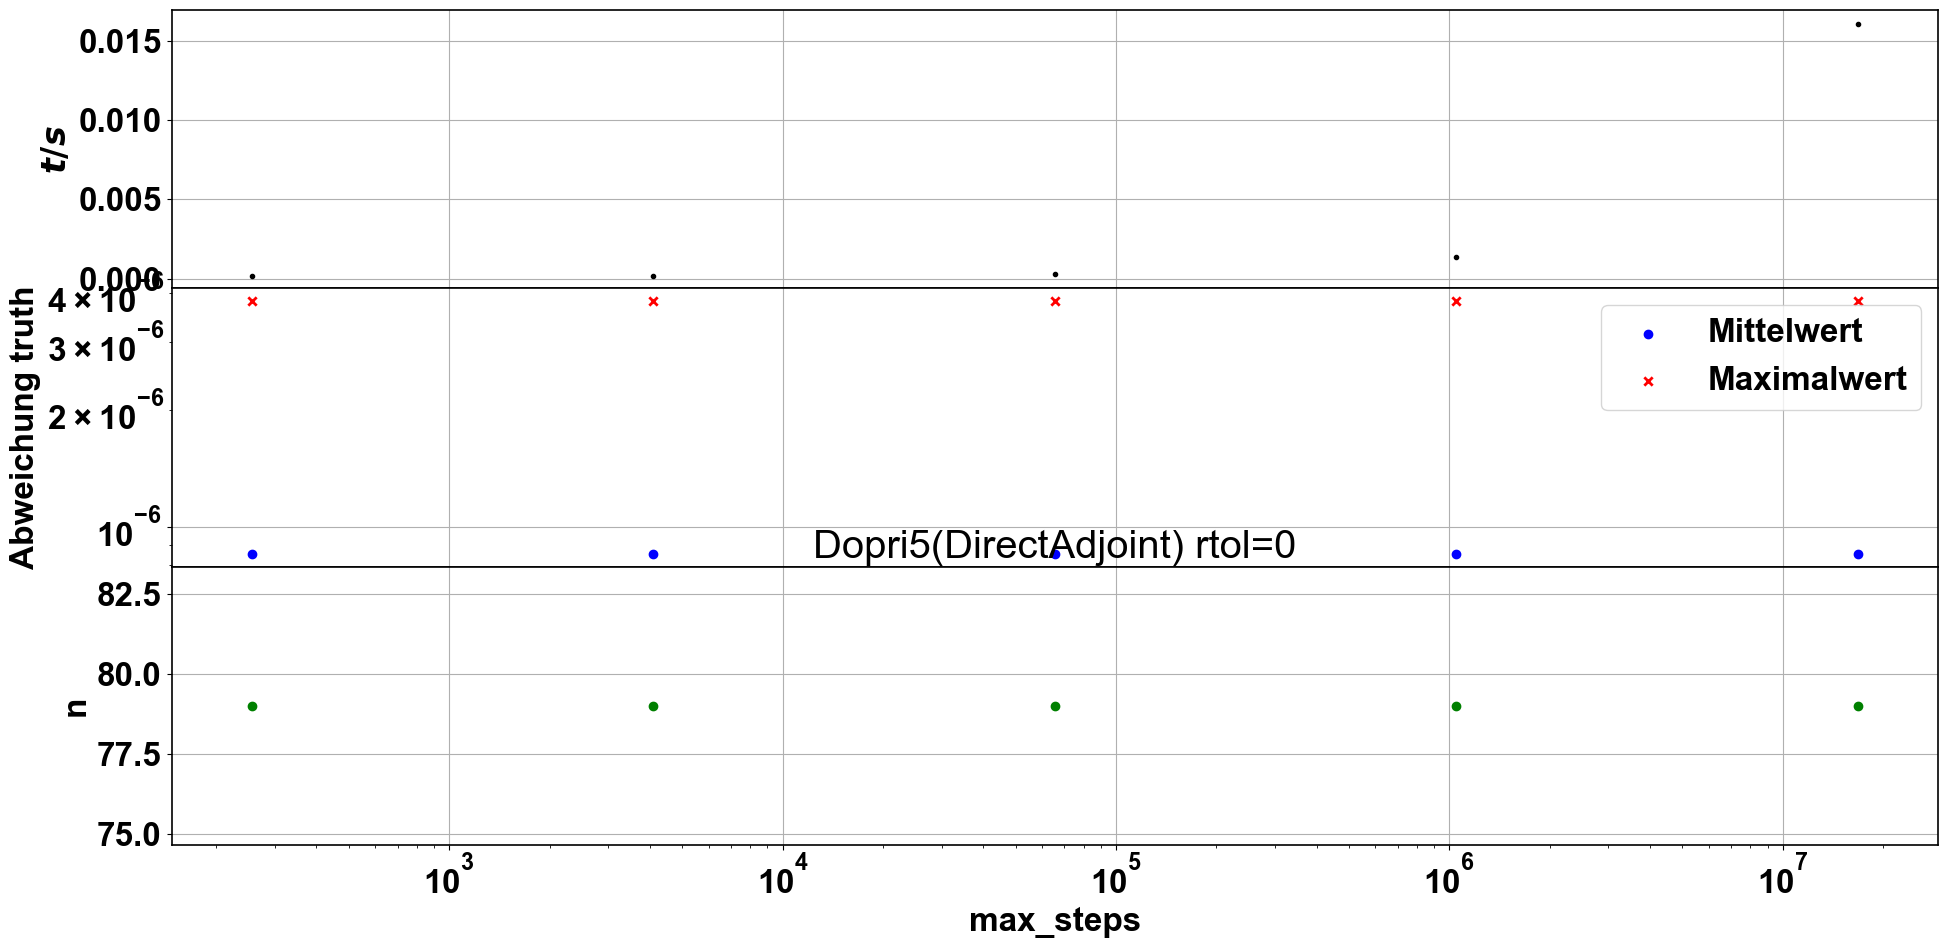

In [90]:
# Plot
fig, ax = plt.subplots(3,1, figsize=(20,10), sharex=True, gridspec_kw={'height_ratios': [3, 3, 3]})
plt.title('Dopri5(DirectAdjoint) rtol=0')
ax[0].set_ylabel('$t/s$')
ax[0].errorbar(df_ds['max_steps'], df_ds['t_mean'], yerr=df_ds['t_std'], color='black', fmt = '.')
ax[0].grid()
ax[1].set_ylabel('Abweichung truth')
ax[1].set_yscale('log')
ax[1].scatter(df_ds['max_steps'], df_ds['abw_mean_dopri'], color='blue', label='Mittelwert', marker='o')
ax[1].scatter(df_ds['max_steps'], df_ds['abw_max_dopri'], color='red', label='Maximalwert', marker='x')
ax[1].grid()
ax[1].legend()
ax[2].set_xlabel('max_steps')
ax[2].set_xscale('log')
ax[2].set_ylabel('n')
ax[2].scatter(df_ds['max_steps'], df_ds['n'], color='green', marker='o')
ax[2].grid()
fig.tight_layout()
fig.subplots_adjust(hspace=0.0)